Last date: 2026-02-06 Last close: 521.25
Obs: 2133 Daily vol (std): 0.02317625367204432
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                        Close   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4368.30
Distribution:      Standardized Student's t   AIC:                           8746.59
Method:                  Maximum Likelihood   BIC:                           8774.92
                                              No. Observations:                 2133
Date:                      Sun, Feb 08 2026   Df Residuals:                     2132
Time:                              09:23:20   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. In

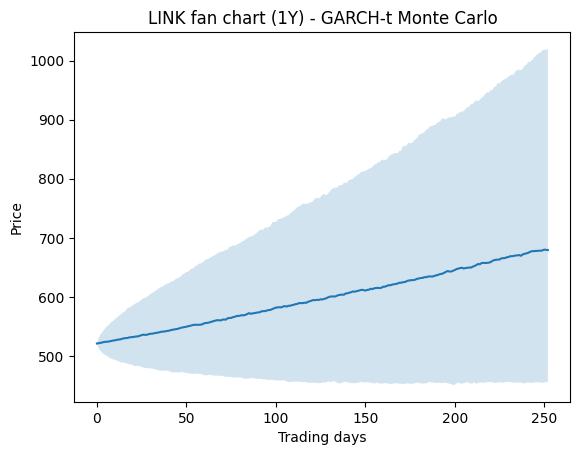

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import t as student_t

CSV_PATH = "protector.csv" 

data = pd.read_csv(CSV_PATH)
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date").set_index("Date")

price = data["Close"].astype(float).dropna()
rets = np.log(price / price.shift(1)).dropna()

# Use % returns for arch package stability
rets_pct = rets * 100.0

print("Last date:", price.index[-1].date(), "Last close:", float(price.iloc[-1]))
print("Obs:", len(rets), "Daily vol (std):", float(rets.std()))

# mean="Constant" is okay; you can also try mean="Zero"
am = arch_model(rets_pct, mean="Constant", vol="Garch", p=1, q=1, dist="t")
res = am.fit(disp="off")
print(res.summary())

# Extract fitted parameters
params = res.params
df = float(params.get("nu", 8.0))  # Student-t degrees of freedom (nu)

HORIZONS = {
    "1M": 21,
    "3M": 63,
    "6M": 126,
    "1Y": 252,
    "3Y": 756,
    "5Y": 1260,
}

N_SIMS = 20000  # increase if you want smoother percentiles
S0 = float(price.iloc[-1])

# Last estimated conditional variance (in %^2)
# res.conditional_volatility is in % units; square for variance
sigma_last = float(res.conditional_volatility.iloc[-1])  # in %
var_last = sigma_last**2

# Helper to simulate returns under GARCH(1,1) with Student-t shocks
def simulate_terminal_prices(days: int, n_sims: int = N_SIMS):
    mu = float(params["mu"]) if "mu" in params else 0.0
    omega = float(params["omega"])
    alpha = float(params["alpha[1]"])
    beta = float(params["beta[1]"])

    var = np.full(n_sims, var_last, dtype=float)  # variance in %^2
    logS = np.full(n_sims, np.log(S0), dtype=float)

    scale = np.sqrt(df / (df - 2.0)) if df > 2 else 1.0

    for _ in range(days):
        z = student_t.rvs(df, size=n_sims) / scale  # unit-variance shocks
        sigma = np.sqrt(var)                         # in %
        r_pct = mu + sigma * z                       # log-return in % (because you fitted log returns*100)

        # ✅ Correct update: log price moves by log-return
        logS += (r_pct / 100.0)

        # GARCH variance update (in % units)
        eps = (r_pct - mu)
        var = omega + alpha * (eps**2) + beta * var
        var = np.clip(var, 1e-12, 1e12)

    return np.exp(logS)

def summarize_prices(prices_T: np.ndarray, label: str):
    p10, p50, p90 = np.percentile(prices_T, [10, 50, 90])
    prob_loss = float(np.mean(prices_T < S0))

    # returns for risk metrics
    simple_ret = prices_T / S0 - 1.0
    var95 = float(np.quantile(simple_ret, 0.05))  # 5% quantile (VaR 95% on returns)
    es95 = float(simple_ret[simple_ret <= var95].mean()) if np.any(simple_ret <= var95) else var95

    return {
        "Horizon": label,
        "Days": HORIZONS[label],
        "P10": float(p10),
        "P50": float(p50),
        "P90": float(p90),
        "Prob_Loss": prob_loss,
        "VaR95_ret": var95,
        "ES95_ret": es95,
    }

results = []
terminal_samples = {}  # store for plotting
for h in HORIZONS:
    prices_T = simulate_terminal_prices(HORIZONS[h], N_SIMS)
    terminal_samples[h] = prices_T
    results.append(summarize_prices(prices_T, h))

out = pd.DataFrame(results).set_index("Horizon")
# Pretty formatting
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("\n=== LINK Distribution Targets (GARCH-t Monte Carlo) ===")
print(out[["Days", "P10", "P50", "P90", "Prob_Loss", "VaR95_ret", "ES95_ret"]])

PLOT_FAN = True
if PLOT_FAN:
    days = 252
    n_paths = 5000

    mu = float(params["mu"]) if "mu" in params else 0.0
    omega = float(params["omega"])
    alpha = float(params["alpha[1]"])
    beta = float(params["beta[1]"])

    var = np.full(n_paths, var_last, dtype=float)
    logS = np.full((n_paths, days + 1), np.log(S0), dtype=float)

    scale = np.sqrt(df / (df - 2.0)) if df > 2 else 1.0

    for t in range(1, days + 1):
        z = student_t.rvs(df, size=n_paths) / scale
        sigma = np.sqrt(var)
        r_pct = mu + sigma * z  # log-return in %

        # ✅ Correct: add log-return directly
        logS[:, t] = logS[:, t - 1] + (r_pct / 100.0)

        eps = (r_pct - mu)
        var = omega + alpha * (eps**2) + beta * var
        var = np.clip(var, 1e-12, 1e12)

    S_paths = np.exp(logS)
    p10 = np.percentile(S_paths, 10, axis=0)
    p50 = np.percentile(S_paths, 50, axis=0)
    p90 = np.percentile(S_paths, 90, axis=0)

    plt.figure()
    plt.fill_between(range(days + 1), p10, p90, alpha=0.2)
    plt.plot(p50)
    plt.title("LINK fan chart (1Y) - GARCH-t Monte Carlo")
    plt.xlabel("Trading days")
    plt.ylabel("Price")
    plt.show()

